In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [3]:
dataset = datasets.ImageFolder(
    root="./data/images_128",
    transform=transform
)

In [4]:
dataloader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True,
    persistent_workers=True,
    prefetch_factor=2,
    num_workers=2,
    pin_memory=True
)

In [5]:
import time


for i, (x, y) in enumerate(dataloader):
    start = time.time()
    print(f"{i+1} batch load time: {time.time()-start}")
    if i==1: break

1 batch load time: 1.9073486328125e-06
2 batch load time: 1.9073486328125e-06


In [6]:
x, y = next(iter(dataloader))
print(x.mean(), x.std())

tensor(0.4435) tensor(0.2386)


In [7]:
len(dataloader)

719

In [8]:
class CnnModel (nn.Module):
    def __init__(self):
        #initialize super 
        super().__init__()
        
        # Kernel
        self.kernel1 = nn.Conv2d(
            in_channels=3,
            out_channels= 8,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        
        self.kernel2 = nn.Conv2d(
            in_channels=8,
            out_channels= 16,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        
        #Linear neural networks
        self.W1 = nn.Parameter(torch.randn(16*32*32, 16) * 0.01)
        self.b1 = nn.Parameter(torch.zeros(16))

        self.W2 = nn.Parameter(torch.randn(16, 2) * 0.01)
        self.b2 = nn.Parameter(torch.zeros(2))
        
        #loss function
        self.criterion  = nn.CrossEntropyLoss()
        
    def forward(self, x):
        
        # first kernel
        x = self.kernel1(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
        
        # second kernel
        x = self.kernel2(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
                
        #reshape images
        x = x.reshape((x.shape[0], -1))
        
        x = x @ self.W1 + self.b1
        x = nn.functional.relu(x)
                
        x = x @ self.W2 + self.b2
                
        return x
    
    def compute_loss(self, y_hat, y):        
        #loss calling
        loss = self.criterion(y_hat, y)
        return loss
    
    def backward_propagation(self, loss, learning_rate=0.01):
        # start loss backward
        loss.backward()
        
        #uses this to 
        with torch.no_grad():
            for param in self.parameters():
                if param.grad is not None:
                    param.data -= learning_rate * param.grad
                    param.grad.zero_()
        
        return loss.item()

In [9]:
def train_epoch(model, dataloader,learning_rate=0.01):
    # using for loop to access each batch
    costs = []
    for x, y in dataloader:
        # transfer to cuda
        x = x.to("cuda", non_blocking=True)
        y = y.to("cuda", non_blocking=True)
        
        #code to stop tracking grad during backtrack
        y_hat = model.forward(x)
        loss = model.compute_loss(y_hat, y)
        cost = model.backward_propagation(loss, learning_rate)
        costs.append(cost)
    
    return costs

In [10]:
# initialize model
model = CnnModel().to("cuda")

In [11]:
import time
import numpy as np

costs = []

for i in range(10):
    #start time
    start = time.time()
    
    #1 epoch process
    epoch = train_epoch(model, dataloader=dataloader)
    
    #end time
    end = time.time()
    
    process_time = end - start
    
    # main cost function
    cost = np.mean(np.array(epoch))    
    costs.append(cost)
    
    print(f"{i+1} Epoch Loss ====> {cost}")
    print(f"Epoch {i+1} training Time = {process_time}")
    print("\n\n")

1 Epoch Loss ====> 0.6931260026711582
Epoch 1 training Time = 8.02120566368103



2 Epoch Loss ====> 0.6922524423028895
Epoch 2 training Time = 6.8107006549835205



3 Epoch Loss ====> 0.6858484653007337
Epoch 3 training Time = 6.758147954940796



4 Epoch Loss ====> 0.6739884842088724
Epoch 4 training Time = 6.748852014541626



5 Epoch Loss ====> 0.6586217406064645
Epoch 5 training Time = 7.023789644241333



6 Epoch Loss ====> 0.6444645353666765
Epoch 6 training Time = 7.05683708190918



7 Epoch Loss ====> 0.628627986379061
Epoch 7 training Time = 6.9370222091674805



8 Epoch Loss ====> 0.6101258292234657
Epoch 8 training Time = 7.0809876918792725



9 Epoch Loss ====> 0.5905910769739138
Epoch 9 training Time = 6.970266342163086



10 Epoch Loss ====> 0.5715969729655641
Epoch 10 training Time = 6.919497489929199





In [13]:
for i in range(10):
    epoch = train_epoch(model, dataloader=dataloader)
    
    cost = np.mean(np.array(epoch))
    
    costs.append(cost)
    
    if (i+1)%10 ==0:
        print(f"{(i+1)} Epoch Loss ====> {cost}")

10 Epoch Loss ====> 0.00023821992727512598


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

epoch = [i+1 for i in range(len(costs))]

display(len(costs))
display(len(epoch))

210

210

<Axes: title={'center': 'Loss Drop function!'}, xlabel='Epoch', ylabel='Loss'>

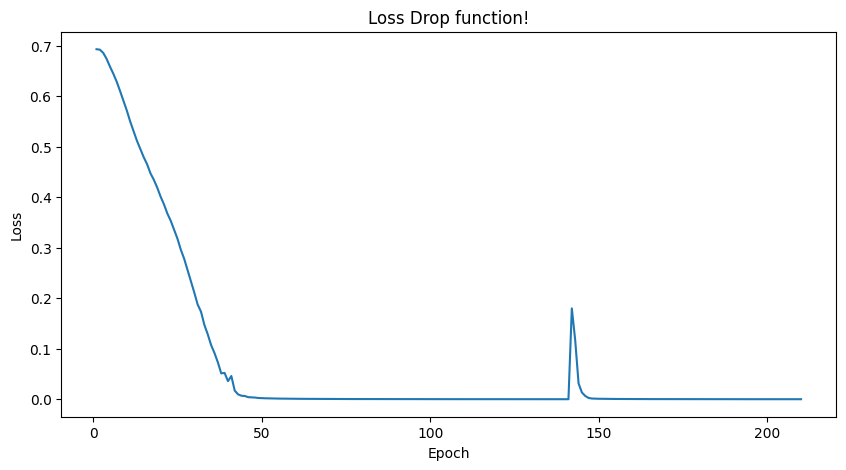

In [15]:

df = pd.DataFrame({"x":epoch, "y":costs})

plt.figure(figsize=(10,5))
plt.title("Loss Drop function!")
plt.ylabel("Loss")
plt.xlabel("Epoch")
sns.lineplot(df, x="x", y="y")

In [18]:
#test model

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    root="./data/valid",
    transform=test_transforms
)

test_dataloader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=2,
    pin_memory=True, 
    prefetch_factor=2, 
    persistent_workers=True
)

print(len(test_dataset))
print(len(test_dataloader))

2000
63


In [19]:
def evaluate_model(model, dataloader, device="cuda"):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    criterion = torch.nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            # loss (optional but useful)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            # predictions
            preds = torch.argmax(outputs, dim=1)

            # store results
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    # combine all batches
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    avg_loss = total_loss / len(dataloader)

    return all_preds, all_labels, avg_loss

In [20]:
y_pred, y_true, loss = evaluate_model(model, test_dataloader)

print("Test Loss:", loss)

Test Loss: 2.111240938542381


In [21]:
len(test_dataloader)

63

In [22]:
def classification_metrics(y_pred, y_true):
    """
    y_pred: tensor of predicted labels (0/1)
    y_true: tensor of true labels (0/1)
    """

    y_pred = y_pred.cpu()
    y_true = y_true.cpu()

    tp = ((y_pred == 1) & (y_true == 1)).sum().item()
    tn = ((y_pred == 0) & (y_true == 0)).sum().item()
    fp = ((y_pred == 1) & (y_true == 0)).sum().item()
    fn = ((y_pred == 0) & (y_true == 1)).sum().item()

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

    print("==== Confusion Matrix ====")
    print(f"TP: {tp}  FP: {fp}")
    print(f"FN: {fn}  TN: {tn}")
    print()
    print("==== Metrics ====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return tp, tn, fp, fn, accuracy, precision, recall, f1

In [23]:
classification_metrics(y_pred=y_pred, y_true=y_true)

==== Confusion Matrix ====
TP: 739  FP: 245
FN: 261  TN: 755

==== Metrics ====
Accuracy : 0.7470
Precision: 0.7510
Recall   : 0.7390
F1 Score : 0.7450


(739,
 755,
 245,
 261,
 0.746999999996265,
 0.7510162601549694,
 0.73899999999261,
 0.7449596724121704)